# Iris Flower Classification

A complete machine learning pipeline to classify iris flowers into 3 species 
based on sepal and petal measurements.

## Project Goals

1. Demonstrate end-to-end ML workflow
2. Compare performance of multiple classification algorithms
3. Identify which features contribute most to classification accuracy
4. Practice professional ML coding standards

## Dataset

The Iris dataset is a classic in ML, containing:
- **150 samples** of iris flowers
- **4 features**: sepal length, sepal width, petal length, petal width
- **3 classes**: setosa, versicolor, virginica (50 samples each)

The dataset is built into scikit-learn, so no manual download is needed.

## 1. Import Libraries

We'll use the following libraries:
- **pandas, numpy**: data manipulation
- **matplotlib, seaborn**: visualization  
- **scikit-learn**: ML algorithms and evaluation tools

We'll compare three different algorithms with varying complexity:
- **Logistic Regression**: simple linear model
- **Decision Tree**: tree-based, interpretable
- **Random Forest**: ensemble of trees, more powerful

In [1]:
# Import library yang akan kita pakai
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset Iris dari scikit-learn (sudah included)
from sklearn.datasets import load_iris

# Tools untuk train/test split dan evaluasi
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Algoritma ML yang akan kita coba
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load and Prepare Dataset

We load the dataset from scikit-learn and convert it into a pandas DataFrame
for easier exploration. We add a `species_name` column for human-readable labels.

In [2]:
# Load dataset Iris
iris = load_iris()

# Buat DataFrame dari data + target
df = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
)

# Tambah kolom 'species' (target)
df['species'] = iris.target

# Tambah kolom 'species_name' (untuk readability)
df['species_name'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

# Tampilkan 5 baris pertama
print("Shape (rows, columns):", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape (rows, columns): (150, 6)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 3. Exploratory Data Analysis (EDA)

Before training any model, we explore the dataset to understand:
- Are there any missing values?
- Is the dataset balanced across classes?
- What are the value ranges and distributions?
- Are there obvious patterns we can exploit?

In [3]:
# Statistik dasar dataset
print("=" * 60)
print("INFO DATASET")
print("=" * 60)
print(df.info())

print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF (mean, std, min, max, dll)")
print("=" * 60)
df.describe()

INFO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None

STATISTIK DESKRIPTIF (mean, std, min, max, dll)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### 3.1 Class Distribution

A balanced dataset (equal samples per class) is ideal for classification.
Imbalanced datasets require special handling (e.g., SMOTE, class weights).

Jumlah sample per spesies:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Visualisasi:


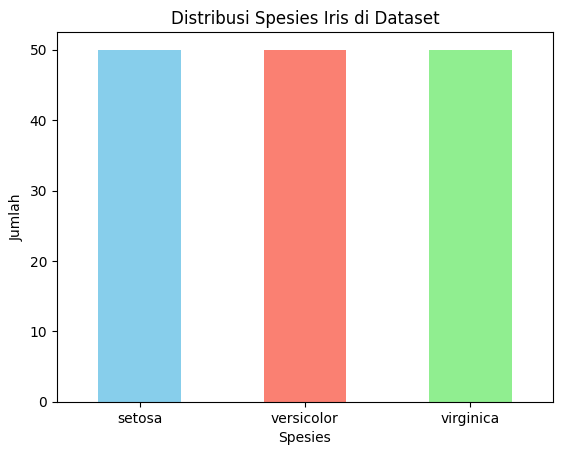

In [4]:
# Cek distribusi class
print("Jumlah sample per spesies:")
print(df['species_name'].value_counts())

print("\nVisualisasi:")
df['species_name'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Distribusi Spesies Iris di Dataset')
plt.xlabel('Spesies')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.show()

### 3.2 Pairplot — Feature Relationships

The pairplot shows scatter plots between every pair of features, colored by class.
This helps us identify:
- Which features are most discriminative?
- Which classes are easily separable?
- Are there outliers or anomalies?

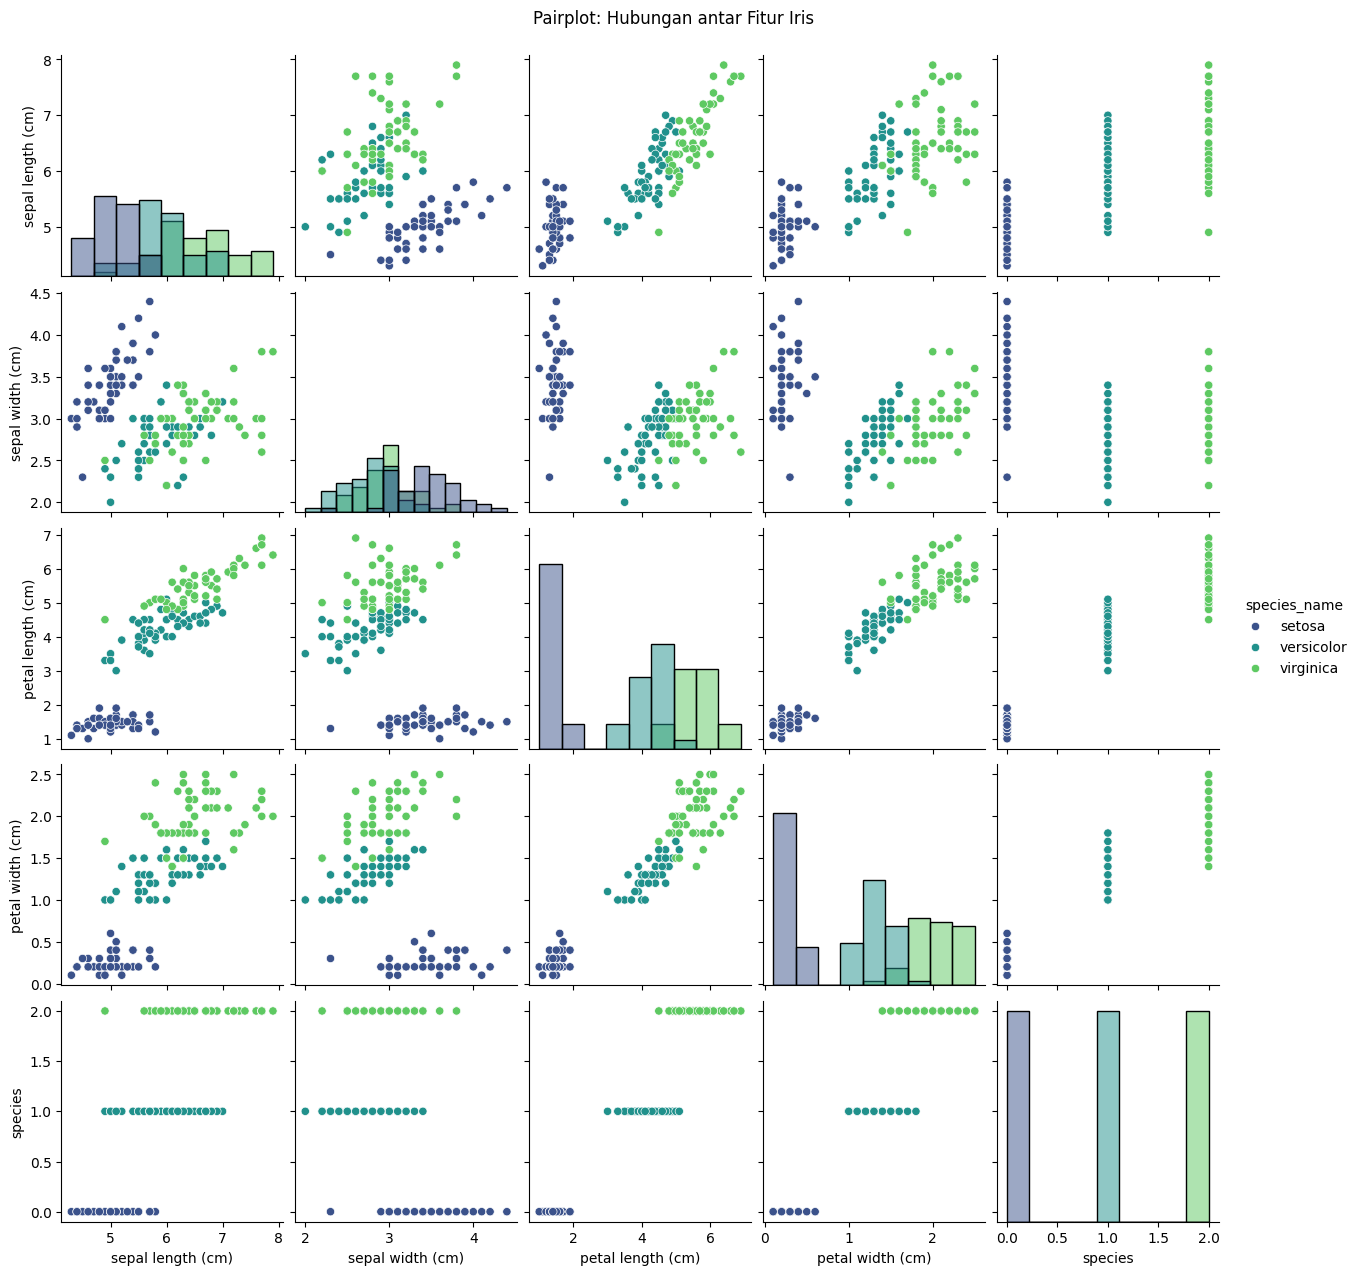

In [5]:
# Pairplot: visualisasi semua kombinasi fitur
sns.pairplot(df, hue='species_name', palette='viridis', diag_kind='hist')
plt.suptitle('Pairplot: Hubungan antar Fitur Iris', y=1.02)
plt.show()

## 4. Prepare Data for Training

We split data into training (80%) and test (20%) sets.

**Why split data?** If we evaluate on training data, the model will appear 
perfect (it has memorized the data). True performance must be measured on 
unseen data — that's the test set.

**Why stratify?** To ensure both train and test sets have equal class distribution. 
Without it, we might get unlucky splits (e.g., 0 setosa in test set).

**Why random_state=42?** For reproducibility — same split every run, enabling 
fair comparison between experiments.

In [6]:
# Pisahkan features (X) dan target (y)
X = df[['sepal length (cm)', 'sepal width (cm)', 
         'petal length (cm)', 'petal width (cm)']]
y = df['species']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Split jadi training (80%) dan testing (20%)
# random_state=42 → hasil reproducible (selalu sama)
# stratify=y → setiap class tetap balanced di train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nDistribusi train: {y_train.value_counts().to_dict()}")
print(f"Distribusi test: {y_test.value_counts().to_dict()}")

Features (X) shape: (150, 4)
Target (y) shape: (150,)

Training set: 120 samples
Test set: 30 samples

Distribusi train: {0: 40, 2: 40, 1: 40}
Distribusi test: {0: 10, 2: 10, 1: 10}


## 5. Train and Compare Models

Best practice: try multiple algorithms with default hyperparameters first 
to establish baselines, then tune the best performer.

Each model is trained on the training set, then evaluated on the test set 
using accuracy and classification report (precision, recall, F1-score).

In [7]:
# Inisialisasi 3 model berbeda
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train dan evaluate setiap model
results = {}

for name, model in models.items():
    print(f"\n{'=' * 60}")
    print(f"Training: {name}")
    print('=' * 60)
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predict di test set
    y_pred = model.predict(X_test)
    
    # Hitung akurasi
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, 
                                target_names=['setosa', 'versicolor', 'virginica']))

# Summary comparison
print("\n" + "=" * 60)
print("PERBANDINGAN AKURASI 3 MODEL")
print("=" * 60)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar = "█" * int(acc * 30)
    print(f"{name:<25} {acc*100:>6.2f}%  {bar}")



Training: Logistic Regression
Accuracy: 0.9667 (96.67%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Training: Decision Tree
Accuracy: 0.9333 (93.33%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Training: Random Forest
Accuracy: 0.9000 (90.00%)

Classification Report:
       

## 6. Detailed Evaluation: Confusion Matrix

The confusion matrix shows where the model makes mistakes:
- **Diagonal**: correct predictions
- **Off-diagonal**: errors

This is more informative than a single accuracy number — it shows **which classes** 
are being confused with which.

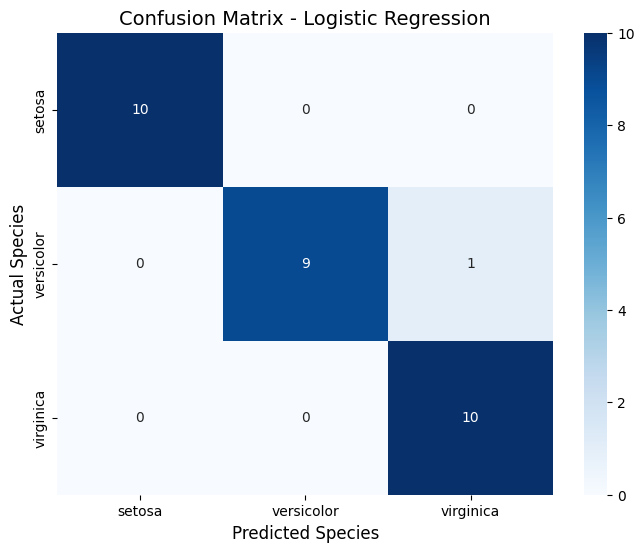


Cara baca confusion matrix:
- Diagonal (kiri atas → kanan bawah) = jawaban BENAR
- Di luar diagonal = jawaban SALAH


In [8]:
# Pilih model terbaik (Logistic Regression)
best_model = LogisticRegression(max_iter=200, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize dengan seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.xlabel('Predicted Species', fontsize=12)
plt.ylabel('Actual Species', fontsize=12)
plt.show()

print("\nCara baca confusion matrix:")
print("- Diagonal (kiri atas → kanan bawah) = jawaban BENAR")
print("- Di luar diagonal = jawaban SALAH")

## 7. Feature Importance Analysis

Random Forest provides built-in feature importance scores. This tells us
which features contribute most to the predictions.

This is valuable for:
- **Model interpretation**: which factors matter?
- **Feature selection**: can we drop low-importance features?
- **Domain insights**: do important features make biological sense?

Feature Importance Ranking:
1. petal width (cm)          0.4372  █████████████████████
2. petal length (cm)         0.4315  █████████████████████
3. sepal length (cm)         0.1163  █████
4. sepal width (cm)          0.0150  


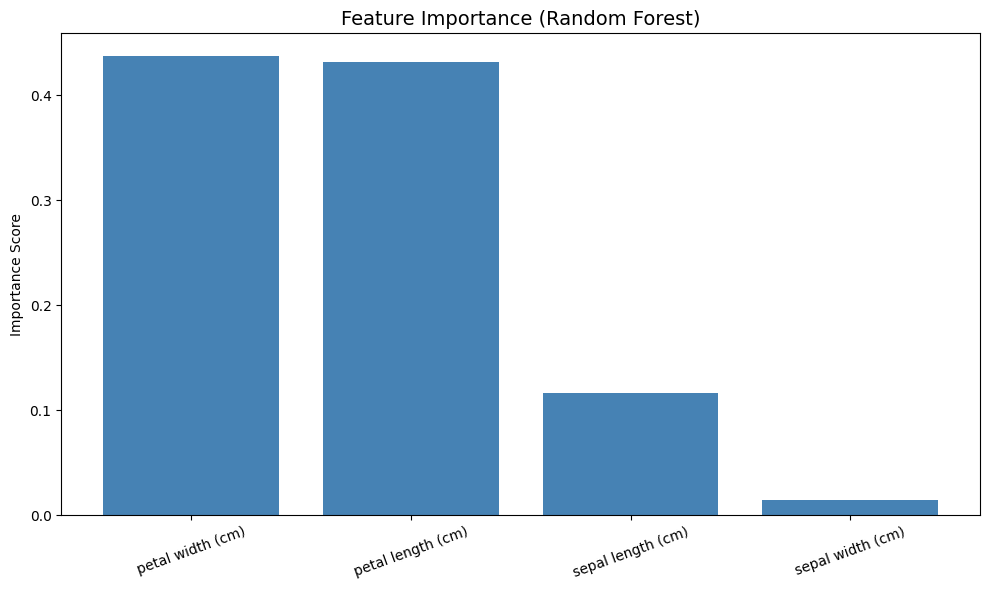

In [9]:
# Train Random Forest (yang punya feature_importances_)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Ambil feature importance
feature_names = X.columns
importances = rf_model.feature_importances_

# Sort dari paling penting
indices = np.argsort(importances)[::-1]

print("Feature Importance Ranking:")
print("=" * 50)
for i, idx in enumerate(indices):
    bar = "█" * int(importances[idx] * 50)
    print(f"{i+1}. {feature_names[idx]:<25} {importances[idx]:.4f}  {bar}")

# Visualize
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices], color='steelblue')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=20)
plt.title('Feature Importance (Random Forest)', fontsize=14)
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

## 8. Predict on New Samples

Finally, we test our model with hypothetical new flower measurements.
The model returns both the predicted class AND the confidence (probability).

Confidence levels are useful in production — we can flag low-confidence 
predictions for human review.

In [10]:
# Bayangkan kamu nemu bunga baru, ukurannya:
# sepal length=5.0, sepal width=3.5, petal length=1.5, petal width=0.2
# Ini setosa kah?

new_flowers = pd.DataFrame({
    'sepal length (cm)': [5.0, 6.5, 7.7],
    'sepal width (cm)': [3.5, 3.0, 3.0],
    'petal length (cm)': [1.5, 4.5, 6.5],
    'petal width (cm)': [0.2, 1.5, 2.0]
})

print("Bunga baru yang akan diprediksi:")
print(new_flowers)

# Predict
predictions = best_model.predict(new_flowers)
probabilities = best_model.predict_proba(new_flowers)

species_names = ['setosa', 'versicolor', 'virginica']

print("\n" + "=" * 60)
print("HASIL PREDIKSI:")
print("=" * 60)
for i, (idx, probs) in enumerate(zip(predictions, probabilities)):
    print(f"\nBunga #{i+1}: predicted = {species_names[idx]}")
    print(f"   Confidence:")
    for j, name in enumerate(species_names):
        bar = "█" * int(probs[j] * 30)
        print(f"   {name:<12} {probs[j]*100:>5.1f}%  {bar}")

Bunga baru yang akan diprediksi:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.0               3.5                1.5               0.2
1                6.5               3.0                4.5               1.5
2                7.7               3.0                6.5               2.0

HASIL PREDIKSI:

Bunga #1: predicted = setosa
   Confidence:
   setosa        97.6%  █████████████████████████████
   versicolor     2.4%  
   virginica      0.0%  

Bunga #2: predicted = versicolor
   Confidence:
   setosa         0.5%  
   versicolor    83.6%  █████████████████████████
   virginica     15.9%  ████

Bunga #3: predicted = virginica
   Confidence:
   setosa         0.0%  
   versicolor     1.2%  
   virginica     98.8%  █████████████████████████████


## 9. Conclusions

### Key Findings

1. **Logistic Regression won (96.67%)** — outperforming the more complex 
   Random Forest (90.00%) and Decision Tree (93.33%). This demonstrates 
   that **simpler models can win on small, well-behaved datasets**.

2. **Petal features dominate** — petal width (43.7%) and petal length (43.1%) 
   contribute 87% of feature importance. Sepal width is nearly useless (1.5%).

3. **Setosa is perfectly separable** — 100% precision and recall, confirming
   the visual observation from the pairplot.

4. **The only confusion** is between versicolor and virginica — these species 
   overlap in petal measurements. This is consistent with botanical literature.

### Why Did Logistic Regression Win?

The Iris dataset has **near-linear class boundaries** (visible in pairplots).
Logistic Regression assumes linear boundaries, which fits perfectly. 
More complex models (Random Forest) tend to **overfit** on small datasets
(150 samples), capturing noise instead of signal.

This is **Occam's Razor in ML**: prefer simpler models that explain the data
adequately. Don't reach for complex models without justification.

### Limitations

- Small dataset (150 samples) — results may not generalize to all iris populations
- Features measured in controlled conditions — real-world flower measurements
  may have more noise
- Only 3 species — real iris taxonomy includes hundreds of species

### Future Improvements

- [ ] Hyperparameter tuning with `GridSearchCV`
- [ ] Cross-validation (k-fold) for more robust evaluation  
- [ ] Try other algorithms: SVM, KNN, XGBoost
- [ ] Deploy as web app using Streamlit
- [ ] Test on additional iris datasets (e.g., from different regions)

### What I Learned

- **End-to-end ML workflow**: from raw data to deployable predictions
- **Importance of EDA**: visualizing data before modeling reveals key insights
- **Train/test discipline**: never evaluate on training data
- **Simple > complex** for small datasets — try baselines first
- **Feature importance** turns black-box ML into actionable insights